# Objectif

Développer un modèle ML qui permet de prédire le future employé à quitter l'entreprise.

# Connecter à Big Query

In [3]:
# Librairies
from google.cloud import bigquery
from google.colab import auth

# Authenticate
auth.authenticate_user()

# Initialize client from Big Query
project_id = "dataanalytics-457219"

# Client
client = bigquery.Client(project=project_id, )

In [4]:
#get the dataset and table
dataset_ref = client.dataset("EmployeeData", project=project_id)
dataset = client.get_dataset(dataset_ref)
table_ref = dataset.table("tbl_hr_data")
table = client.get_table(table_ref)
table.schema

[SchemaField('satisfaction_level', 'FLOAT', 'NULLABLE', None, None, (), None),
 SchemaField('last_evaluation', 'FLOAT', 'NULLABLE', None, None, (), None),
 SchemaField('number_project', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('average_montly_hours', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('time_spend_company', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Work_accident', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Quit_the_Company', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('promotion_last_5years', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Departments', 'STRING', 'NULLABLE', None, None, (), None),
 SchemaField('salary', 'STRING', 'NULLABLE', None, None, (), None),
 SchemaField('employee_id', 'STRING', 'NULLABLE', None, None, (), None)]

In [5]:
new_table_ref = dataset.table("tbl_new_employees")
new_table = client.get_table(new_table_ref)
new_table.schema

[SchemaField('satisfaction_level', 'FLOAT', 'NULLABLE', None, None, (), None),
 SchemaField('last_evaluation', 'FLOAT', 'NULLABLE', None, None, (), None),
 SchemaField('number_project', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('average_montly_hours', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('time_spend_company', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Work_accident', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Quit_the_Company', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('promotion_last_5years', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Departments', 'STRING', 'NULLABLE', None, None, (), None),
 SchemaField('salary', 'STRING', 'NULLABLE', None, None, (), None),
 SchemaField('employee_id', 'STRING', 'NULLABLE', None, None, (), None)]

In [6]:
# Coonvert to dataframe
df = client.list_rows(table=table).to_dataframe()
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,Quit_the_Company,promotion_last_5years,Departments,salary,employee_id
0,0.38,0.53,2,157,3,0,1,0,sales,low,EMP00001
1,0.80,0.86,5,262,6,0,1,0,sales,medium,EMP00002
2,0.11,0.88,7,272,4,0,1,0,sales,medium,EMP00003
3,0.72,0.87,5,223,5,0,1,0,sales,low,EMP00004
4,0.37,0.52,2,159,3,0,1,0,sales,low,EMP00005


In [7]:
# Coonvert to dataframe
df2 = client.list_rows(table=new_table).to_dataframe()
df2.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,Quit_the_Company,promotion_last_5years,Departments,salary,employee_id
0,0.537849,0.122914,2,208,2,0,0,0,IT,high,NE15043
1,0.056211,0.322600,2,229,5,1,0,0,IT,low,NE15086
2,0.555186,0.555949,2,187,3,0,0,0,RandD,medium,NE15035
3,0.605273,0.713086,2,218,3,0,0,0,RandD,high,NE15069
4,0.043437,0.162372,2,175,3,0,0,0,RandD,high,NE15082


# Construire le modéle

### Installer pycaret

In [8]:
#!pip install pycaret

# Coder et entrainer le modéle

In [2]:
from pycaret.classification import *

In [9]:
setup(data=df, target='Quit_the_Company', session_id=123, ignore_features=['Employee_ID'], categorical_features=['Departments', 'salary'])

,Description,Value
0,Session id,123
1,Target,Quit_the_Company
2,Target type,Binary
3,Original data shape,"(15004, 11)"
4,Transformed data shape,"(15004, 22)"
5,Transformed train set shape,"(10502, 22)"
6,Transformed test set shape,"(4502, 22)"
7,Ignore features,1
8,Numeric features,7
9,Categorical features,2


In [10]:
compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9853,0.9932,0.9505,0.9876,0.9686,0.9591,0.9594,0.9270
dummy,Dummy Classifier,0.7617,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1030


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=123, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)

In [11]:
lightgbm8_model = create_model('lightgbm')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9800,0.9879,0.9323,0.9832,0.9571,0.9440,0.9446
1,0.9791,0.9939,0.9363,0.9751,0.9553,0.9416,0.9420
2,0.9905,0.9972,0.9720,0.9878,0.9798,0.9736,0.9737
3,0.9771,0.9926,0.9400,0.9631,0.9514,0.9365,0.9366
4,0.9838,0.9940,0.9320,1.0000,0.9648,0.9543,0.9553
5,0.9914,0.9936,0.9640,1.0000,0.9817,0.9761,0.9764
6,0.9867,0.9940,0.9560,0.9876,0.9715,0.9628,0.9631
7,0.9867,0.9941,0.9520,0.9917,0.9714,0.9627,0.9631
8,0.9857,0.9888,0.9480,0.9916,0.9693,0.9600,0.9604


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [12]:
final_df = predict_model(lightgbm8_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9851,0.9943,0.9543,0.9827,0.9683,0.9586,0.9588


In [13]:
final_df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,Departments,salary,employee_id,Quit_the_Company,prediction_label,prediction_score
1679,0.43,0.55,2,159,3,0,0,RandD,low,EMP01680,1,1,0.9935
4665,0.63,0.93,3,236,4,0,0,sales,high,EMP04666,0,0,0.9940
1076,0.09,0.79,6,276,4,0,0,sales,medium,EMP01077,1,1,0.9993
1253,0.85,1.00,4,234,5,0,0,hr,low,EMP01254,1,1,0.9937
2570,0.80,0.96,3,257,5,0,0,support,medium,EMP02571,0,1,0.8298


In [14]:
new_predictions = predict_model(lightgbm8_model,data= df2)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.8500,0,0.0000,0.0000,0.0000,0.0000,0.0000


In [15]:
new_predictions.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,Departments,salary,employee_id,Quit_the_Company,prediction_label,prediction_score
0,0.537849,0.122914,2,208,2,0,0,IT,high,NE15043,0,0,0.9996
1,0.056211,0.322600,2,229,5,1,0,IT,low,NE15086,0,1,0.9755
2,0.555186,0.555949,2,187,3,0,0,RandD,medium,NE15035,0,0,0.9937
3,0.605273,0.713086,2,218,3,0,0,RandD,high,NE15069,0,0,0.9980
4,0.043437,0.162372,2,175,3,0,0,RandD,high,NE15082,0,1,0.6908


In [16]:
new_predictions["prediction_label"].value_counts()

,count
prediction_label,
0,85
1,15


In [17]:
# Write back to big query
new_predictions.to_gbq("EmployeeData.pilot-predictions",
                       project_id, chunksize=None,
                       if_exists="replace")

100%|██████████| 1/1 [00:00<00:00, 2269.65it/s]


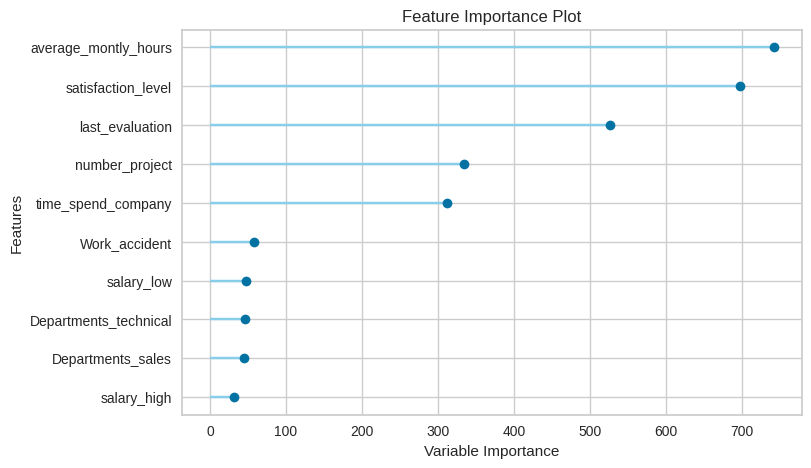

In [18]:
plot_model(lightgbm8_model, plot="feature")

In [19]:
# Create a feature table
lightgbm8_model.feature_name_

['satisfaction_level',
 'last_evaluation',
 'number_project',
 'average_montly_hours',
 'time_spend_company',
 'Work_accident',
 'promotion_last_5years',
 'Departments_management',
 'Departments_product_mng',
 'Departments_sales',
 'Departments_IT',
 'Departments_technical',
 'Departments_RandD',
 'Departments_support',
 'Departments_hr',
 'Departments_marketing',
 'Departments_accounting',
 'salary_medium',
 'salary_low',
 'salary_high',
 'employee_id']

In [20]:
lightgbm8_model.feature_importances_

array([698, 526, 334, 742, 312,  58,  10,   9,  12,  44,  16,  46,  11,
        29,  24,   3,  27,  20,  47,  32,   0], dtype=int32)

In [21]:
import pandas as pd
features_table = pd.DataFrame(zip(lightgbm8_model.feature_name_, lightgbm8_model.feature_importances_), columns=["feature", "importance"])
features_table

,feature,importance
0,satisfaction_level,698
1,last_evaluation,526
2,number_project,334
3,average_montly_hours,742
4,time_spend_company,312
5,Work_accident,58
6,promotion_last_5years,10
7,Departments_management,9
8,Departments_product_mng,12
9,Departments_sales,44


In [22]:
# Write to big query
features_table.to_gbq("EmployeeData.features_table",
                       project_id, chunksize=None,
                       if_exists="replace")

100%|██████████| 1/1 [00:00<00:00, 8144.28it/s]
